# 2 — Modelling, Ablation and Explainability

Loads the artefacts written by `1-cohort-construction.ipynb` and runs the four-arm
feature ablation, the survey-weighted descriptive analysis, two sensitivity analyses,
and the SHAP explainability figures.

**Run notebook 1 first.** This notebook reads `data/processed/` and does not touch the
raw `.xpt` files.

---

### 1. CONFIGURATION

In [52]:
import json, re, warnings
import json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
    RandomizedSearchCV, ParameterGrid)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (roc_auc_score, accuracy_score,
    balanced_accuracy_score, f1_score, confusion_matrix)
from xgboost import XGBClassifier
import shap

In [34]:
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

CYCLES = ["E", "F", "G"]
FILES = ["DEMO", "BMX", "CBC", "ENX", "MCQ", "OCQ", "RDQ", "SMQ", "SPX"]
WT_COL, PSU_COL, STRATA_COL = "WTMEC2YR", "SDMVPSU", "SDMVSTRA"
N_CYCLES = len(CYCLES)

In [ ]:
_CANDIDATES = [Path("../data/proc"), Path("data/proc"),
               Path("../../data/proc")]
PROC_DIR = next((p.resolve() for p in _CANDIDATES if p.is_dir()), None)
if PROC_DIR is None:
    raise FileNotFoundError(
        "No data/proc directory found — run 1-cohort-construction.ipynb first. "
        "Looked in: " + ", ".join(str(p.resolve()) for p in _CANDIDATES))

# FIX 15: figures and tables go to Results/, not the working directory.
RESULTS_DIR = PROC_DIR.parent.parent / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Processed dir:", PROC_DIR)
print("Results dir  :", RESULTS_DIR)

Processed dir: /Users/farhan/projects/Asthma-COPD-V2/data/proc
Results dir  : /Users/farhan/projects/Asthma-COPD-V2/Results


### 2. LOAD THE COHORT AND SURVEY FRAME

Replaces the original cells that re-ran file discovery, the nine-component merge, and
`build_cohort`. Those now live in notebook 1, so the phenotype definitions exist in
exactly one place.

In [36]:
cohort = pd.read_parquet(PROC_DIR / "cohort.parquet")
svy = pd.read_parquet(PROC_DIR / "survey_frame.parquet")

with open(PROC_DIR / "cohort_counts.json") as fh:
    COHORT_COUNTS = json.load(fh)

In [37]:
def fix_xport_zeros(df, tol=1e-70):
    """pandas.read_sas (pandas-dev #30051) returns 5.397605346934028e-79 --
    the smallest IBM hex float -- for some XPORT fields holding 0.0. These are
    ZEROS, not missing values: mapping them to NaN would delete real responses
    such as RDQ090 code 0 = "Never", the modal answer among wheezers.
    Also matters for WTMEC2YR: a zero weight stored as a denormal is > 0 and
    slips past the (w > 0) filter in taylor_estimate, inflating reported n.
    Floats only, so integer columns such as `target` keep their dtype."""
    flt = df.select_dtypes(include=["float"]).columns
    df[flt] = df[flt].mask(df[flt].abs() < tol, 0.0)
    return df

In [38]:
# STOPGAP: the parquet files were written before the sweep existed in
# notebook 1. Fix at source there and re-run, then this becomes a no-op.
n_before = int((cohort.select_dtypes(include=["float"]).abs() < 1e-70).sum().sum()
               + (svy.select_dtypes(include=["float"]).abs() < 1e-70).sum().sum())
cohort = fix_xport_zeros(cohort)
svy = fix_xport_zeros(svy)
print(f"XPORT denormals swept: {n_before}")

assert {"target", "outcome_fev1_fvc_ratio"} <= set(cohort.columns)
assert {"age_eligible", "asthma_only", "copd_only", "overlap",
        "no_disease", "group", "w6yr"} <= set(svy.columns)
assert int((svy["group"] == 1).sum()) == COHORT_COUNTS["n_asthma"]
assert int((svy["group"] == 0).sum()) == COHORT_COUNTS["n_copd"]

print("Cohort:", cohort.shape, "| target counts:",
      cohort["target"].value_counts().to_dict())
print("ACO excluded:", COHORT_COUNTS["n_overlap_excluded"])
print("Survey frame:", svy.shape, "|", int(svy["age_eligible"].sum()), "age-eligible")
print("Zero MEC weight, age-eligible:",
      int((svy.loc[svy["age_eligible"], WT_COL] == 0).sum()))

XPORT denormals swept: 149432
Cohort: (922, 362) | target counts: {1: 794, 0: 128}
ACO excluded: 73
Survey frame: (30442, 364) | 10536 age-eligible
Zero MEC weight, age-eligible: 317


### 3. FEATURE CONSTRUCTION

In [39]:
# ---------------------------------------------------------------------------
# FEATURE_MAP corrected against the RDQ_E / RDQ_F / RDQ_G codebooks
# (verified identical across all three cycles, 2007-2012).
#
#   RDQ031  Coughing most days - over 3 mo period     1 Yes / 2 No / 7 / 9
#   RDQ050  Bring up phlegm most days - 3 mo period   1 Yes / 2 No / 7 / 9
#   RDQ070  Wheezing or whistling in chest - past yr  1 Yes / 2 No / 7 / 9   [GATE]
#   RDQ080  # wheezing/whistling attacks past year    COUNT 1-12 / 7777 / 9999
#   RDQ090  Wheezing disturb sleep in past year       0 Never / 1 >=1 night wk /
#                                                     2 <1 night wk / 7 / 9
#   RDQ100  Chest sound wheezy during exercise        1 Yes / 2 No / 7 / 9
#   RDQ140  Had dry cough at night in past year       1 Yes / 2 No / 7 / 9  [NOT gated]
#
# RDQ080/090/100 are administered only if RDQ070 == 1.
# RDQ031/RDQ050 are asked of all participants aged 40+.
# RDQ140 is asked of all participants aged 1+ and is NOT gated on wheeze.
# ---------------------------------------------------------------------------
FEATURE_MAP = {
    "RIAGENDR": "gender", "RIDAGEYR": "age", "RIDRETH1": "race_ethnicity",
    "DMDEDUC2": "education", "INDFMPIR": "poverty_income_ratio",
    "SMQ020": "ever_smoked_100", "SMQ040": "current_smoking_status",
    "OCD150": "work_status",
    # --- respiratory symptoms (corrected) ---
    "RDQ031": "cough_most_days_3mo",      # was "wheeze_past_12mo"  (swapped)
    "RDQ050": "phlegm_most_days_3mo",     # was absent entirely
    "RDQ070": "wheeze_past_12mo",         # was "cough_most_days"   (swapped)
    "RDQ080": "wheeze_attacks_past_yr",   # was "phlegm_most_days"; is a COUNT
    "RDQ090": "wheeze_disturbs_sleep",    # was "cough_phlegm_3mo"; is ORDINAL
    "RDQ100": "wheeze_exercise",          # unchanged - was already correct
    "RDQ140": "dry_cough_night",          # was "wheeze_disturbs_sleep"
    "BMXBMI": "bmi", "BMXWAIST": "waist_circumference",
    "LBXWBCSI": "wbc_count", "LBXEOPCT": "eosinophil_pct",
    "LBDEONO": "eosinophil_count", "ENXMEAN": "feno_mean",
    "SPXNFEV1": "fev1", "SPXNFVC": "fvc", "SPXNPEF": "pef",
}

# wheeze_attacks_past_yr is a 1-12 episode count, so it belongs here rather
# than being one-hot encoded into a dozen spurious levels.
NUMERIC_COLS = ["age", "poverty_income_ratio", "bmi", "waist_circumference",
                "wbc_count", "eosinophil_pct", "eosinophil_count", "feno_mean",
                "wheeze_attacks_past_yr",
                "fev1", "fvc", "pef", "fev1_fvc_ratio"]

SPX_FEATURES = ["fev1", "fvc", "pef", "fev1_fvc_ratio"]
LAB_FEATURES = ["wbc_count", "eosinophil_pct", "eosinophil_count", "feno_mean"]

In [40]:
# Refused / don't-know codes for CATEGORICAL items only.
# These must NOT be applied to wheeze_attacks_past_yr, where 7 and 9 are
# valid answers (7 attacks, 9 attacks); that variable uses 7777/9999.
SPECIAL_CODES_CAT = {7: np.nan, 9: np.nan, 77: np.nan, 99: np.nan,
                     777: np.nan, 999: np.nan}
SPECIAL_CODES_COUNT = {7777: np.nan, 9999: np.nan}

In [41]:
def build_features(cohort):
    X = cohort[list(FEATURE_MAP.keys())].rename(columns=FEATURE_MAP).copy()
    X["fev1_fvc_ratio"] = X["fev1"] / X["fvc"]
    y = cohort["target"].copy()

    categorical_cols = [c for c in X.columns if c not in NUMERIC_COLS]

    for c in categorical_cols:
        X[c] = X[c].replace(SPECIAL_CODES_CAT)
    X["wheeze_attacks_past_yr"] = X["wheeze_attacks_past_yr"].replace(SPECIAL_CODES_COUNT)

    # SMQ040 is asked only of SMQ020 == 1, so it is structurally missing for
    # every never-smoker. Give them an explicit level instead of letting
    # SimpleImputer(most_frequent) assign them a smoking status.
    X.loc[X["ever_smoked_100"] == 2, "current_smoking_status"] = 0.0

    # RDQ080/090/100 are gated on RDQ070 (wheeze). For non-wheezers the
    # answers are known, not missing: zero attacks, sleep never disturbed,
    # no exertional wheeze. RDQ140 is ungated and is deliberately left alone.
    no_wheeze = X["wheeze_past_12mo"] == 2
    X.loc[no_wheeze, "wheeze_attacks_past_yr"] = 0.0
    X.loc[no_wheeze, "wheeze_disturbs_sleep"] = 0.0   # 0 = "Never"
    X.loc[no_wheeze, "wheeze_exercise"] = 2.0         # 2 = "No"

    return X, y, categorical_cols

In [42]:
X, y, categorical_cols = build_features(cohort)
print("Feature matrix:", X.shape, "| categorical:", len(categorical_cols))

# Confirm no special codes survived into the encoded categories.
for c in categorical_cols:
    levels = sorted(X[c].dropna().unique())
    assert not ({7, 9, 77, 99} & set(levels)), f"{c} still has special codes: {levels}"
    print(f"  {c:24s} {levels}")

Feature matrix: (922, 25) | categorical: 12
  gender                   [1.0, 2.0]
  race_ethnicity           [1.0, 2.0, 3.0, 4.0, 5.0]
  education                [1.0, 2.0, 3.0, 4.0, 5.0]
  ever_smoked_100          [1.0, 2.0]
  current_smoking_status   [0.0, 1.0, 2.0, 3.0]
  work_status              [1.0, 2.0, 3.0, 4.0]
  cough_most_days_3mo      [1.0, 2.0]
  phlegm_most_days_3mo     [1.0, 2.0]
  wheeze_past_12mo         [1.0, 2.0]
  wheeze_disturbs_sleep    [0.0, 1.0, 2.0]
  wheeze_exercise          [1.0, 2.0]
  dry_cough_night          [1.0, 2.0]


### 4. PREPROCESSING, MODELS and METRICS

In [43]:
def build_preprocessor(categorical_cols, numeric_cols):
    return ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), numeric_cols),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols),
    ])


def get_feature_names(preprocessor, numeric_cols, categorical_cols):
    ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    return list(numeric_cols) + list(ohe.get_feature_names_out(categorical_cols))


def get_model_specs(scale_pos_weight):
    return {
        "Logistic Regression": (
            LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, class_weight="balanced"),
            {"clf__C": np.logspace(-3, 2, 20), "clf__penalty": ["l2"]}),
        # NOTE: SVC(probability=True) fits Platt scaling by internal CV. On this
        # sample size that occasionally disagrees with decision_function and
        # produces folds below chance. Report SVM with median and IQR, or drop it.
        "SVM": (
            SVC(probability=True, random_state=RANDOM_SEED, class_weight="balanced"),
            {"clf__C": np.logspace(-2, 2, 15), "clf__gamma": ["scale", "auto"],
             "clf__kernel": ["rbf"]}),
        "Random Forest": (
            RandomForestClassifier(random_state=RANDOM_SEED, class_weight="balanced"),
            {"clf__n_estimators": [200, 400, 600], "clf__max_depth": [None, 5, 8, 12],
             "clf__min_samples_leaf": [1, 2, 4, 8]}),
        "Extra Trees": (
            ExtraTreesClassifier(random_state=RANDOM_SEED, class_weight="balanced"),
            {"clf__n_estimators": [200, 400, 600], "clf__max_depth": [None, 5, 8, 12],
             "clf__min_samples_leaf": [1, 2, 4, 8]}),
        "XGBoost (regularized)": (
            XGBClassifier(random_state=RANDOM_SEED, eval_metric="logloss",
                          scale_pos_weight=scale_pos_weight, verbosity=0, n_jobs=1),
            {"clf__n_estimators": [200, 400], "clf__max_depth": [2, 3, 4, 5],
             "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
             "clf__reg_alpha": [0, 0.1, 0.5, 1.0], "clf__reg_lambda": [1.0, 2.0, 5.0, 10.0],
             "clf__subsample": [0.6, 0.8, 1.0], "clf__colsample_bytree": [0.6, 0.8, 1.0]}),
    }


def capped_n_iter(params, n_iter):
    """FIX 9: the logistic grid has only 20 points, so n_iter=30 made sklearn
    warn and silently fall back. Cap explicitly and record the real value."""
    try:
        return min(n_iter, len(ParameterGrid(params)))
    except TypeError:          # a genuine distribution, not an exhaustible grid
        return n_iter


def make_search(clf, params, prep, n_iter, cv):
    # FIX 12: clone the preprocessor per model. RandomizedSearchCV clones
    # internally so the original was not actually contaminated, but sharing a
    # mutable transformer across five pipelines is a trap waiting to be sprung.
    pipe = Pipeline([("prep", clone(prep)), ("clf", clf)])
    return RandomizedSearchCV(pipe, params, n_iter=capped_n_iter(params, n_iter),
                              scoring="roc_auc", cv=cv,
                              random_state=RANDOM_SEED, n_jobs=-1)


def best_threshold(y_true, proba):
    ts = np.linspace(0.05, 0.95, 181)
    scores = [balanced_accuracy_score(y_true, (proba >= t).astype(int)) for t in ts]
    i = int(np.argmax(scores))
    return float(ts[i]), float(scores[i])


def evaluate(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {"AUROC": roc_auc_score(y_true, proba),
            # NOTE: Accuracy is measured at a threshold tuned for balanced
            # accuracy on an 86:14 split. It is reported for continuity only.
            "Accuracy": accuracy_score(y_true, pred),
            "Balanced_Accuracy": balanced_accuracy_score(y_true, pred),
            "Macro_F1": f1_score(y_true, pred, average="macro"),
            "Asthma_Sensitivity": tp / (tp + fn) if (tp + fn) else np.nan,
            "COPD_Sensitivity": tn / (tn + fp) if (tn + fp) else np.nan}


def make_arm(X, drop_cols):
    Xa = X.drop(columns=[c for c in drop_cols if c in X.columns])
    num_c = [c for c in NUMERIC_COLS if c in Xa.columns]
    cat_c = [c for c in Xa.columns if c not in num_c]
    return Xa, num_c, cat_c

### 5. EVALUATION PROTOCOLS

In [45]:
def run_single_split(X, y, numeric_cols, categorical_cols, n_iter=30):
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=RANDOM_SEED, stratify=y_temp)
    print(f"train={len(y_train)} val={len(y_val)} test={len(y_test)} "
          f"| val COPD n={(y_val == 0).sum()} test COPD n={(y_test == 0).sum()}")
    # NOTE: the threshold is tuned on roughly 26 COPD cases. Expect the
    # threshold and COPD sensitivity to be unstable at this denominator.

    spw = (y_train == 0).sum() / (y_train == 1).sum()
    prep = build_preprocessor(categorical_cols, numeric_cols)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

    fitted, test_probs, results = {}, {}, []
    for name, (clf, params) in get_model_specs(spw).items():
        search = make_search(clf, params, prep, n_iter, cv)
        search.fit(X_train, y_train)
        best = search.best_estimator_
        fitted[name] = best
        t_star, _ = best_threshold(y_val, best.predict_proba(X_val)[:, 1])
        proba_test = best.predict_proba(X_test)[:, 1]
        test_probs[name] = proba_test
        m = evaluate(y_test, proba_test, t_star)
        m.update({"Model": name, "CV_best_AUC": search.best_score_, "Threshold": t_star})
        results.append(m)
        print(f"{name}: innerCV={search.best_score_:.4f} thr={t_star:.3f} "
              f"test={m['AUROC']:.4f} balacc={m['Balanced_Accuracy']:.4f}")
    return pd.DataFrame(results).sort_values("AUROC", ascending=False), fitted, test_probs, y_test


def run_nested_repeated_cv(X, y, numeric_cols, categorical_cols,
                           n_splits=5, n_repeats=10, n_iter=20,
                           inner_val_frac=0.25, verbose=True):
    rkf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats,
                                  random_state=RANDOM_SEED)
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    rows, n_folds = [], n_splits * n_repeats

    for fold_i, (tr, te) in enumerate(rkf.split(X, y), start=1):
        X_otr, y_otr = X.iloc[tr], y.iloc[tr]
        X_te, y_te = X.iloc[te], y.iloc[te]
        X_in, X_val, y_in, y_val = train_test_split(
            X_otr, y_otr, test_size=inner_val_frac,
            random_state=RANDOM_SEED, stratify=y_otr)
        spw = (y_in == 0).sum() / (y_in == 1).sum()
        prep = build_preprocessor(categorical_cols, numeric_cols)

        for name, (clf, params) in get_model_specs(spw).items():
            search = make_search(clf, params, prep, n_iter, inner_cv)
            search.fit(X_in, y_in)
            best = search.best_estimator_
            t_star, _ = best_threshold(y_val, best.predict_proba(X_val)[:, 1])
            m = evaluate(y_te, best.predict_proba(X_te)[:, 1], t_star)
            # Repeat index lets the paired comparison bootstrap over repeats
            # rather than over correlated folds.
            m.update({"Model": name, "Fold": fold_i,
                      "Repeat": (fold_i - 1) // n_splits + 1,
                      "Threshold": t_star, "Inner_CV_AUC": search.best_score_})
            rows.append(m)
        if verbose and fold_i % 5 == 0:
            print(f"    fold {fold_i}/{n_folds}", flush=True)
    return pd.DataFrame(rows)


def summarise_folds(fold_df):
    """FIX 10: the original named the fold quantiles _lo and _hi, which reads as
    a confidence interval. Repeated-CV folds share training data heavily and
    there is no unbiased estimator of the variance of k-fold CV
    (Bengio & Grandvalet, 2004). These are the spread of point estimates across
    correlated resamples — report them as such, and take genuine intervals from
    the test-set bootstrap below."""
    metrics = ["AUROC", "Balanced_Accuracy", "Macro_F1",
               "Asthma_Sensitivity", "COPD_Sensitivity", "Threshold"]
    out = []
    for model, g in fold_df.groupby("Model"):
        row = {"Model": model, "N_folds": len(g)}
        for m in metrics:
            row[f"{m}_mean"] = g[m].mean()
            row[f"{m}_sd"] = g[m].std(ddof=1)
            row[f"{m}_median"] = g[m].median()
            row[f"{m}_p025"] = g[m].quantile(0.025)
            row[f"{m}_p975"] = g[m].quantile(0.975)
        out.append(row)
    return pd.DataFrame(out).sort_values("AUROC_mean", ascending=False)


def paired_arm_delta(folds_a, folds_b, metric="AUROC",
                     n_boot=2000, seed=RANDOM_SEED):
    """FIX 11: arm differences were reported as bare numbers. Because every arm
    uses the same RepeatedStratifiedKFold seed, folds are paired, so the
    difference can carry an interval. Resampling is done over REPEATS, not
    folds: the five folds within a repeat partition the same data and are not
    independent."""
    a = folds_a[["Model", "Fold", "Repeat", metric]].rename(columns={metric: "a"})
    b = folds_b[["Model", "Fold", "Repeat", metric]].rename(columns={metric: "b"})
    m = a.merge(b, on=["Model", "Fold", "Repeat"], validate="one_to_one")
    # validate="one_to_one" rejects duplicate keys but NOT missing ones - a
    # truncated arm merges silently. Fail loudly instead.
    if len(m) != len(a) or len(m) != len(b):
        raise ValueError(
            f"paired merge lost rows: a={len(a)}, b={len(b)}, merged={len(m)}. "
            "The two arms were not run over the same folds.")
    m["d"] = m["a"] - m["b"]

    rng = np.random.default_rng(seed)
    out = []
    for model, g in m.groupby("Model"):
        # Repeat-level means are the independent unit. Folds within a repeat
        # partition the same data, so both the bootstrap AND the signed-rank
        # test must operate at this level - testing on all 50 folds treats one
        # shared repeat effect as five observations and is anticonservative.
        per_repeat = g.groupby("Repeat")["d"].mean().to_numpy()
        boots = rng.choice(per_repeat, size=(n_boot, len(per_repeat)),
                           replace=True).mean(axis=1)
        out.append({
            "Model": model,
            "delta_mean": float(per_repeat.mean()),
            "boot_lo": float(np.quantile(boots, 0.025)),
            "boot_hi": float(np.quantile(boots, 0.975)),
            "n_repeats": len(per_repeat),
            "wilcoxon_p": (float(stats.wilcoxon(per_repeat).pvalue)
                           if np.any(per_repeat != 0) else np.nan),
        })
    return pd.DataFrame(out).sort_values("delta_mean", ascending=False)


def bootstrap_ci(y_true, proba, threshold, n_boot=2000, seed=RANDOM_SEED):
    """Class-stratified bootstrap of the test set with the model and threshold
    held fixed. Captures test-set sampling variability only, not variability
    from refitting the model."""
    rng = np.random.default_rng(seed)
    y_true, proba = np.asarray(y_true), np.asarray(proba)
    ipos, ineg = np.where(y_true == 1)[0], np.where(y_true == 0)[0]
    reps = []
    for _ in range(n_boot):
        bs = np.concatenate([rng.choice(ipos, len(ipos), replace=True),
                             rng.choice(ineg, len(ineg), replace=True)])
        try:
            reps.append(evaluate(y_true[bs], proba[bs], threshold))
        except ValueError:
            continue
    reps = pd.DataFrame(reps)
    return pd.DataFrame({"point": pd.Series(evaluate(y_true, proba, threshold)),
                         "ci_lo": reps.quantile(0.025), "ci_hi": reps.quantile(0.975)})

### 6. SINGLE-SPLIT-FULL FEATURE SET

Arm A is label-contaminated by construction: spirometry defines the COPD phenotype.
These numbers are the leakage upper bound, not a screening result.

In [46]:
Xa, num_a, cat_a = make_arm(X, [])
results_df, fitted, test_probs, y_test = run_single_split(X, y, num_a, cat_a)
print("\n=== Single split, full feature set (Arm A) ===")
print(results_df.to_string(index=False))
results_df.to_csv(RESULTS_DIR / "single_split_arm_A.csv", index=False)

print("\n=== Bootstrap 95% CIs (test set) ===")
for name, proba in test_probs.items():
    thr = float(results_df.loc[results_df["Model"] == name, "Threshold"].iloc[0])
    print(f"\n--- {name} (thr={thr:.3f}) ---")
    print(bootstrap_ci(y_test, proba, thr).round(4).to_string())

train=552 val=185 test=185 | val COPD n=26 test COPD n=26
Logistic Regression: innerCV=0.9085 thr=0.510 test=0.8926 balacc=0.8056
SVM: innerCV=0.9291 thr=0.050 test=0.0939 balacc=0.5000
Random Forest: innerCV=0.9489 thr=0.710 test=0.9582 balacc=0.9182
Extra Trees: innerCV=0.8985 thr=0.805 test=0.9260 balacc=0.8696
XGBoost (regularized): innerCV=0.9445 thr=0.520 test=0.9620 balacc=0.9018

=== Single split, full feature set (Arm A) ===
   AUROC  Accuracy  Balanced_Accuracy  Macro_F1  Asthma_Sensitivity  COPD_Sensitivity                 Model  CV_best_AUC  Threshold
0.962022  0.886486           0.901790  0.812942            0.880503          0.923077 XGBoost (regularized)     0.944526      0.520
0.958152  0.859459           0.918239  0.788813            0.836478          1.000000         Random Forest     0.948898      0.710
0.925980  0.886486           0.869618  0.804035            0.893082          0.846154           Extra Trees     0.898539      0.805
0.892598  0.859459           0.805

### 7. SURVEY DESIGN DIAGNOSTICS

In [49]:
def add_pooled_weight(df):
    df = df.copy()
    df["w6yr"] = df[WT_COL] / N_CYCLES
    return df


cohort_w = add_pooled_weight(cohort)
print("Unweighted n:", len(cohort_w))
print("Sum of 6-year MEC weights:", f"{cohort_w['w6yr'].sum():,.0f}")
print("Strata:", cohort_w[STRATA_COL].nunique(),
      "| PSUs:", cohort_w.groupby(STRATA_COL)[PSU_COL].nunique().sum())
print("Zero-weight rows (not MEC-examined):", int((cohort_w[WT_COL] == 0).sum()))

print(sorted(c for c in svy.columns if c.upper().startswith("WT")))

Unweighted n: 922
Sum of 6-year MEC weights: 11,039,455
Strata: 45 | PSUs: 93
Zero-weight rows (not MEC-examined): 25
['WTINT2YR', 'WTMEC2YR']


### 8. TIMING SMOKE TEST

One repeat at low `n_iter`, to size the full run before committing to it.

In [50]:
%%time
_X, _n, _c = make_arm(X, SPX_FEATURES)
_ = run_nested_repeated_cv(_X, y, _n, _c, n_repeats=1, n_iter=10, verbose=False)

CPU times: user 7.05 s, sys: 541 ms, total: 7.59 s
Wall time: 31.8 s


### 9. FOUR ARM ABLATION
Arm D was previously run in a separate cell against a separately computed baseline.
All four arms now share one loop and one seed, so the folds pair up for the delta
comparison below.

In [53]:
ARMS = {
    "A_full":     [],
    "B_no_ratio": ["fev1_fvc_ratio"],   # as specified: the derived column only.
                                        # fev1 and fvc remain, so this isolates
                                        # the explicit ratio, not its information.
    "C_no_spx":   SPX_FEATURES,
    "D_final":    SPX_FEATURES + ["race_ethnicity"],
}

RESUME = True          # skip arms whose fold CSV already exists

arm_folds, arm_summary, arm_features = {}, {}, {}
for arm, drop in ARMS.items():
    Xa, num_c, cat_c = make_arm(X, drop)
    arm_features[arm] = {"n_features": int(Xa.shape[1]),
                         "dropped": drop,
                         "features": list(Xa.columns)}
    path = RESULTS_DIR / f"nested_cv_folds_{arm}.csv"

    if RESUME and path.exists():
        folds = pd.read_csv(path)
        print(f"\n=== Arm {arm} === ({Xa.shape[1]} features) "
              f"loaded from cache, {len(folds)} rows", flush=True)
    else:
        print(f"\n=== Arm {arm} === ({Xa.shape[1]} features)", flush=True)
        t0 = time.time()
        folds = run_nested_repeated_cv(Xa, y, num_c, cat_c,
                                       n_splits=5, n_repeats=10, n_iter=20)
        folds.insert(0, "Arm", arm)     # makes the four CSVs concatenable
        folds.to_csv(path, index=False)
        print(f"  done in {(time.time() - t0) / 60:.1f} min", flush=True)

    arm_folds[arm] = folds
    arm_summary[arm] = summarise_folds(folds)
    print(arm_summary[arm].round(4).to_string(index=False))

with open(RESULTS_DIR / "arm_features.json", "w") as fh:
    json.dump(arm_features, fh, indent=2)

# Mean and SD together, so Table 2 comes straight off this frame.
ablation = pd.DataFrame({
    f"{a}_{stat}": arm_summary[a].set_index("Model")[f"AUROC_{stat}"]
    for a in ARMS for stat in ("mean", "sd")
})
means = pd.DataFrame({a: arm_summary[a].set_index("Model")["AUROC_mean"] for a in ARMS})
ablation["ratio_effect"]     = means["A_full"] - means["B_no_ratio"]
ablation["total_spx_effect"] = means["A_full"] - means["C_no_spx"]
ablation["race_effect"]      = means["C_no_spx"] - means["D_final"]
ablation["A_minus_D"]        = means["A_full"] - means["D_final"]

assert not ablation.isna().any().any(), "a model is missing from at least one arm"

print("\n=== Ablation: nested-CV AUROC by arm (mean, SD across 50 folds) ===")
print(ablation.round(4).to_string())
print("\nFeature counts:", {a: v["n_features"] for a, v in arm_features.items()})
ablation.to_csv(RESULTS_DIR / "ablation_four_arm.csv")


=== Arm A_full === (25 features)


    fold 5/50
    fold 10/50
    fold 15/50
    fold 20/50
    fold 25/50
    fold 30/50
    fold 35/50
    fold 40/50
    fold 45/50
    fold 50/50
  done in 8.6 min
                Model  N_folds  AUROC_mean  AUROC_sd  AUROC_median  AUROC_p025  AUROC_p975  Balanced_Accuracy_mean  Balanced_Accuracy_sd  Balanced_Accuracy_median  Balanced_Accuracy_p025  Balanced_Accuracy_p975  Macro_F1_mean  Macro_F1_sd  Macro_F1_median  Macro_F1_p025  Macro_F1_p975  Asthma_Sensitivity_mean  Asthma_Sensitivity_sd  Asthma_Sensitivity_median  Asthma_Sensitivity_p025  Asthma_Sensitivity_p975  COPD_Sensitivity_mean  COPD_Sensitivity_sd  COPD_Sensitivity_median  COPD_Sensitivity_p025  COPD_Sensitivity_p975  Threshold_mean  Threshold_sd  Threshold_median  Threshold_p025  Threshold_p975
        Random Forest       50      0.9597    0.0116        0.9613      0.9298      0.9773                  0.8973                0.0246                    0.9013                  0.8435                  0.9298         0.7992  

### 9a. PAIRED ARM COMPARISONS

The headline claim of the paper is a magnitude — roughly 0.15 AUROC of leakage — so it
needs an interval. Folds are paired across arms by construction. Resampling is over
the ten repeats rather than the fifty folds, since folds within a repeat partition the
same data.

In [54]:
COMPARISONS = [
    ("A_full", "D_final",    "Total leakage + race (A - D)"),
    ("A_full", "C_no_spx",   "All spirometry (A - C)"),
    ("A_full", "B_no_ratio", "Ratio and FVC (A - B)"),
    ("C_no_spx", "D_final",  "Race/ethnicity (C - D)"),
]

delta_rows = []
for a, b, label in COMPARISONS:
    d = paired_arm_delta(arm_folds[a], arm_folds[b])
    d.insert(0, "Comparison", label)
    delta_rows.append(d)
    print(f"\n=== {label} ===")
    print(d.round(4).to_string(index=False))

deltas = pd.concat(delta_rows, ignore_index=True)
deltas.to_csv(RESULTS_DIR / "paired_arm_deltas.csv", index=False)


=== Total leakage + race (A - D) ===
                  Comparison                 Model  delta_mean  boot_lo  boot_hi  n_repeats  wilcoxon_p
Total leakage + race (A - D)                   SVM      0.1575   0.0804   0.2278         10      0.0098
Total leakage + race (A - D)         Random Forest      0.1561   0.1509   0.1619         10      0.0020
Total leakage + race (A - D) XGBoost (regularized)      0.1556   0.1510   0.1597         10      0.0020
Total leakage + race (A - D)   Logistic Regression      0.1325   0.1302   0.1350         10      0.0020
Total leakage + race (A - D)           Extra Trees      0.1318   0.1274   0.1366         10      0.0020

=== All spirometry (A - C) ===
            Comparison                 Model  delta_mean  boot_lo  boot_hi  n_repeats  wilcoxon_p
All spirometry (A - C)         Random Forest      0.1426   0.1379   0.1478         10      0.0020
All spirometry (A - C) XGBoost (regularized)      0.1410   0.1378   0.1442         10      0.0020
All spiromet

## 10. Survey-weighted estimation

Taylor series linearization over `SDMVSTRA` / `SDMVPSU`, applied as a domain estimator:
the full frame is retained and observations outside the domain contribute zero, which
is what keeps the standard errors correct.

In [55]:
def taylor_estimate(df, yvar, wvar="w6yr", stratum="SDMVSTRA", psu="SDMVPSU",
                    domain=None, alpha=0.05):
    """Weighted mean/proportion with a design-based standard error."""
    d = df.copy()
    if domain:
        inside = d[domain].fillna(False).astype(bool)
    else:
        inside = pd.Series(True, index=d.index)

    valid = inside & d[yvar].notna() & d[wvar].notna() & (d[wvar] > 0)

    w = np.where(valid, d[wvar].to_numpy(dtype=float), 0.0)
    yv = np.where(valid,
                  pd.to_numeric(d[yvar], errors="coerce").fillna(0).to_numpy(float),
                  0.0)

    sw = w.sum()
    if sw <= 0:
        raise ValueError(f"{yvar}: no positive weight in domain")
    theta = float((w * yv).sum() / sw)

    z = w * (yv - theta) / sw   # zero outside the domain, by construction

    work = pd.DataFrame({"z": z, "h": d[stratum].to_numpy(), "a": d[psu].to_numpy()})
    psu_tot = work.groupby(["h", "a"], sort=False)["z"].sum().reset_index()

    # NOTE: single-PSU strata contribute zero variance rather than being
    # collapsed, which biases the SE very slightly downward. Immaterial at
    # df ~ 49, but state the convention in the methods.
    var, singletons = 0.0, 0
    for _, g in psu_tot.groupby("h", sort=False):
        n_h = len(g)
        if n_h < 2:
            singletons += 1
            continue
        dev = g["z"].to_numpy() - g["z"].mean()
        var += n_h / (n_h - 1) * float((dev ** 2).sum())

    se = float(np.sqrt(max(var, 0.0)))
    dof = max(len(psu_tot) - psu_tot["h"].nunique(), 1)
    tcrit = stats.t.ppf(1 - alpha / 2, dof)

    return {"variable": yvar, "estimate": theta, "stderr": se,
            "lower_ci": theta - tcrit * se, "upper_ci": theta + tcrit * se,
            "df": dof, "n_unweighted": int(valid.sum()), "sum_weights": sw,
            "singleton_strata": singletons}


def taylor_by_domain(df, yvar, domain_col, levels, **kw):
    """Run taylor_estimate once per level of a categorical domain column."""
    out = []
    for lvl in levels:
        d = df.copy()
        d["_dom"] = (d[domain_col] == lvl)
        r = taylor_estimate(d, yvar, domain="_dom", **kw)
        r["domain"] = lvl
        out.append(r)
    return pd.DataFrame(out)


print("Functions loaded.")

Functions loaded.


### 10a. PREVALENCE and TABLE 1

**Interpretation caveat for the manuscript.** COPD-only requires self-report *and*
spirometric confirmation, while anyone without usable spirometry falls into "Neither"
by construction. The resulting COPD-only figure is therefore far below published US
prevalence and is a *phenotype* prevalence, not a disease prevalence. Label it that way
or a reviewer will read it as an error.

In [56]:
# --- A. Population prevalence, adults 40-79 ---
print("=== Weighted prevalence, US adults aged 40-79 ===")
prev_rows = []
for flag, label in [("asthma_only", "Asthma only"),
                    ("copd_only", "COPD only"),
                    ("overlap", "Asthma-COPD overlap"),
                    ("no_disease", "Neither")]:
    r = taylor_estimate(svy, flag, domain="age_eligible")
    r["label"] = label
    prev_rows.append(r)
    print(f"  {label:22s} {r['estimate']*100:6.2f}%  "
          f"(SE {r['stderr']*100:.2f}, 95% CI "
          f"{r['lower_ci']*100:.2f}-{r['upper_ci']*100:.2f}, df={r['df']})")

prev = pd.DataFrame(prev_rows)
print(f"\n  Sum of four categories: {prev['estimate'].sum()*100:.2f}% (should be 100.00)")
asth = prev.loc[prev['label'] == 'Asthma only', 'estimate'].iloc[0]
copd = prev.loc[prev['label'] == 'COPD only', 'estimate'].iloc[0]
unw = COHORT_COUNTS["n_asthma"] / COHORT_COUNTS["n_copd"]
print(f"  Asthma:COPD ratio - population (weighted) {asth/copd:.2f} "
      f"vs cohort composition (unweighted) {unw:.2f}")
print("    These answer different questions and are not expected to match.")
prev.to_csv(RESULTS_DIR / "weighted_prevalence.csv", index=False)

# --- B. Table 1 by disease group ---
CONTINUOUS = {
    "RIDAGEYR": "Age, years", "BMXBMI": "BMI, kg/m2",
    "BMXWAIST": "Waist circumference, cm", "INDFMPIR": "Poverty-income ratio",
    "LBXWBCSI": "WBC count, 1000 cells/uL", "LBXEOPCT": "Eosinophils, %",
    "LBDEONO": "Eosinophil count, 1000 cells/uL", "ENXMEAN": "FeNO, ppb",
    "SPXNFEV1": "FEV1, mL", "SPXNFVC": "FVC, mL",
}

svy["female"] = (svy["RIAGENDR"] == 2).astype(float)
svy["ever_smoker"] = (svy["SMQ020"] == 1).astype(float)

# FIX: SMQ040 is asked only of SMQ020 == 1, so it is NaN for every never-smoker.
# .isin([1, 2]) returns False for NaN, which silently folded never-smokers and
# non-respondents into the "not current smoker" denominator. Define the
# variable over the whole population instead: never-smokers are genuine
# non-current-smokers; refused/don't-know stay missing and drop out via `valid`.
svy["current_smoker"] = np.where(
    svy["SMQ020"] == 2, 0.0,                                   # never smoked 100+
    np.where(svy["SMQ040"].isin([1, 2]), 1.0,                  # every day / some days
             np.where(svy["SMQ040"] == 3, 0.0, np.nan)))       # not at all / missing

svy["nh_white"] = (svy["RIDRETH1"] == 3).astype(float)
svy["nh_black"] = (svy["RIDRETH1"] == 4).astype(float)
BINARY = {"female": "Female", "ever_smoker": "Ever smoked 100+ cigarettes",
          "current_smoker": "Current smoker",
          "nh_white": "Non-Hispanic White", "nh_black": "Non-Hispanic Black"}

svy["group_label"] = svy["group"].map({1.0: "Asthma only", 0.0: "COPD only"})

rows = []
for var, label in {**CONTINUOUS, **BINARY}.items():
    if var not in svy.columns:
        print(f"  SKIPPED {label}: column absent")
        rows.append({"Variable": label, "Type": "FAILED (absent)"})
        continue
    try:
        r = taylor_by_domain(svy, var, "group_label", ["Asthma only", "COPD only"])
        rec = {"Variable": label, "Type": "mean" if var in CONTINUOUS else "proportion"}
        for _, row in r.iterrows():
            rec[f"{row['domain']} est"] = row["estimate"]
            rec[f"{row['domain']} SE"] = row["stderr"]
            rec[f"{row['domain']} n"] = row["n_unweighted"]
        rows.append(rec)
    except Exception as exc:
        # FIX: a bare except previously printed one line and left no trace in
        # the table, so a missing row was easy to overlook in long output.
        print(f"  SKIPPED {label}: {type(exc).__name__}: {exc}")
        rows.append({"Variable": label, "Type": "FAILED"})

table1 = pd.DataFrame(rows)
print("\n=== Table 1: survey-weighted characteristics by group ===")
print(table1.round(4).to_string(index=False))
if (table1["Type"].astype(str).str.startswith("FAILED")).any():
    print("\n  WARNING: some rows failed - see above.")
table1.to_csv(RESULTS_DIR / "table1_weighted.csv", index=False)

# NOTE for the manuscript:
# - The n columns are COMPLETE CASES PER VARIABLE, not group sizes. FEV1 will
#   show ~521 for asthma against 128 for COPD while age shows 794/128. Say so
#   in the table caption or a reader will take n as the group size.
# - Continuous means are over complete cases within each group. FEV1 and FeNO
#   are missing differentially by group, so those rows carry nonresponse bias
#   regardless of the weighting.

=== Weighted prevalence, US adults aged 40-79 ===
  Asthma only              7.25%  (SE 0.53, 95% CI 6.19-8.31, df=49)
  COPD only                1.35%  (SE 0.18, 95% CI 0.98-1.71, df=49)
  Asthma-COPD overlap      0.76%  (SE 0.11, 95% CI 0.55-0.98, df=49)
  Neither                 90.64%  (SE 0.60, 95% CI 89.43-91.86, df=49)

  Sum of four categories: 100.00% (should be 100.00)
  Asthma:COPD ratio - population (weighted) 5.39 vs cohort composition (unweighted) 6.20
    These answer different questions and are not expected to match.


/var/folders/2j/ryb6v7ns2t9760z6yvvtp83m0000gn/T/ipykernel_95154/2336395174.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  svy["female"] = (svy["RIAGENDR"] == 2).astype(float)
/var/folders/2j/ryb6v7ns2t9760z6yvvtp83m0000gn/T/ipykernel_95154/2336395174.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  svy["ever_smoker"] = (svy["SMQ020"] == 1).astype(float)
/var/folders/2j/ryb6v7ns2t9760z6yvvtp83m0000gn/T/ipykernel_95154/2336395174.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of c


=== Table 1: survey-weighted characteristics by group ===
                       Variable       Type  Asthma only est  Asthma only SE  Asthma only n  COPD only est  COPD only SE  COPD only n
                     Age, years       mean          55.8184          0.3815            769        62.2168        0.8787          128
                     BMI, kg/m2       mean          31.6633          0.3215            758        28.4472        0.7949          126
        Waist circumference, cm       mean         105.6374          0.8917            716       103.2930        2.3072          123
           Poverty-income ratio       mean           2.9392          0.1246            697         2.4392        0.1727          113
       WBC count, 1000 cells/uL       mean           7.3991          0.1109            722         7.5888        0.3061          124
                 Eosinophils, %       mean           3.4192          0.1245            720         2.7733        0.2197          124
Eosinophil

### 11. SENSITIVITY: complete spirometry only

Asthma cases without spirometry receive a median-imputed ratio that sits above 0.70,
so missingness itself carries signal. Restricting to complete spirometry removes that
channel — but it also shifts case mix and class balance, so the comparison is not a
clean imputation effect. Both are reported below.

In [57]:
spx_obs = X[["fev1", "fvc", "pef"]].notna().all(axis=1)
print(f"Complete spirometry: {spx_obs.sum()} of {len(X)}")
print("By group:", y[spx_obs].value_counts().to_dict())
print(f"COPD share — all cases {(y == 0).mean():.3f}, "
      f"complete-spirometry {(y[spx_obs] == 0).mean():.3f}")

X_s, y_s = X[spx_obs], y[spx_obs]
X_sa, num_sa, cat_sa = make_arm(X_s, [])

folds_complete = run_nested_repeated_cv(X_sa, y_s, num_sa, cat_sa,
                                        n_splits=5, n_repeats=10, n_iter=20)
folds_complete.insert(0, "Arm", "A_complete_spx")
folds_complete.to_csv(RESULTS_DIR / "nested_cv_folds_A_complete_spx.csv", index=False)
summary_complete = summarise_folds(folds_complete)
print(summary_complete.round(4).to_string(index=False))

print("\n=== Arm A: all cases vs complete-spirometry only ===")
comp = pd.DataFrame({
    "A_all_cases": arm_summary["A_full"].set_index("Model")["AUROC_mean"],
    "A_complete_spx": summary_complete.set_index("Model")["AUROC_mean"],
})
comp["imputation_effect"] = comp["A_all_cases"] - comp["A_complete_spx"]
print(comp.round(4).to_string())
comp.to_csv(RESULTS_DIR / "imputation_sensitivity.csv")

# NOTE: not paired — different row sets — so no paired interval here. The
# difference conflates imputation with the case-mix and prevalence shift
# printed above. Both arms remain label-contaminated.

Complete spirometry: 649 of 922
By group: {1: 521, 0: 128}
COPD share — all cases 0.139, complete-spirometry 0.197
    fold 5/50
    fold 10/50
    fold 15/50
    fold 20/50
    fold 25/50
    fold 30/50
    fold 35/50
    fold 40/50
    fold 45/50
    fold 50/50
                Model  N_folds  AUROC_mean  AUROC_sd  AUROC_median  AUROC_p025  AUROC_p975  Balanced_Accuracy_mean  Balanced_Accuracy_sd  Balanced_Accuracy_median  Balanced_Accuracy_p025  Balanced_Accuracy_p975  Macro_F1_mean  Macro_F1_sd  Macro_F1_median  Macro_F1_p025  Macro_F1_p975  Asthma_Sensitivity_mean  Asthma_Sensitivity_sd  Asthma_Sensitivity_median  Asthma_Sensitivity_p025  Asthma_Sensitivity_p975  COPD_Sensitivity_mean  COPD_Sensitivity_sd  COPD_Sensitivity_median  COPD_Sensitivity_p025  COPD_Sensitivity_p975  Threshold_mean  Threshold_sd  Threshold_median  Threshold_p025  Threshold_p975
        Random Forest       50      0.9377    0.0195        0.9419      0.9022      0.9678                  0.8560                

### 12. SHAP — Arm D, the final reported model

Arm D is spirometry-free and race-free. Random Forest is used as a representative
tree-based model.

The original fitted the model three separate times across cells 20, 21 and 22 — once
for the raw ranking and twice more because the education labels were added afterwards.
Labels are now complete up front and the model is fitted once.

=== Summed mean |SHAP| by original variable (armD) ===
                      label  mean_abs_shap
Ever smoked 100+ cigarettes         0.0957
     Current smoking status         0.0687
                        Age         0.0455
                        BMI         0.0375
     Wheeze, past 12 months         0.0293
                        Sex         0.0288
                       FeNO         0.0197
         Wheeze on exertion         0.0168
       Poverty-income ratio         0.0164
Wheezing attacks, past year         0.0153
    Wheeze disturbing sleep         0.0109
        Waist circumference         0.0109
                  Education         0.0090
            Eosinophils (%)         0.0089
                  WBC count         0.0082


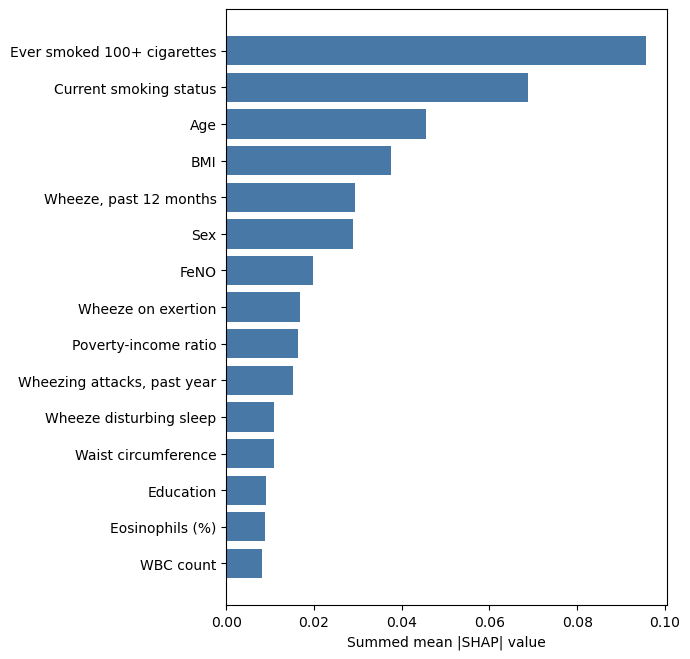


Beeswarm: 32 of 39 columns retained (7 mirrored dummies removed)
  hidden from beeswarm: gender_1.0, ever_smoked_100_2.0, cough_most_days_3mo_2.0, phlegm_most_days_3mo_2.0, wheeze_past_12mo_2.0, wheeze_exercise_2.0, dry_cough_night_2.0


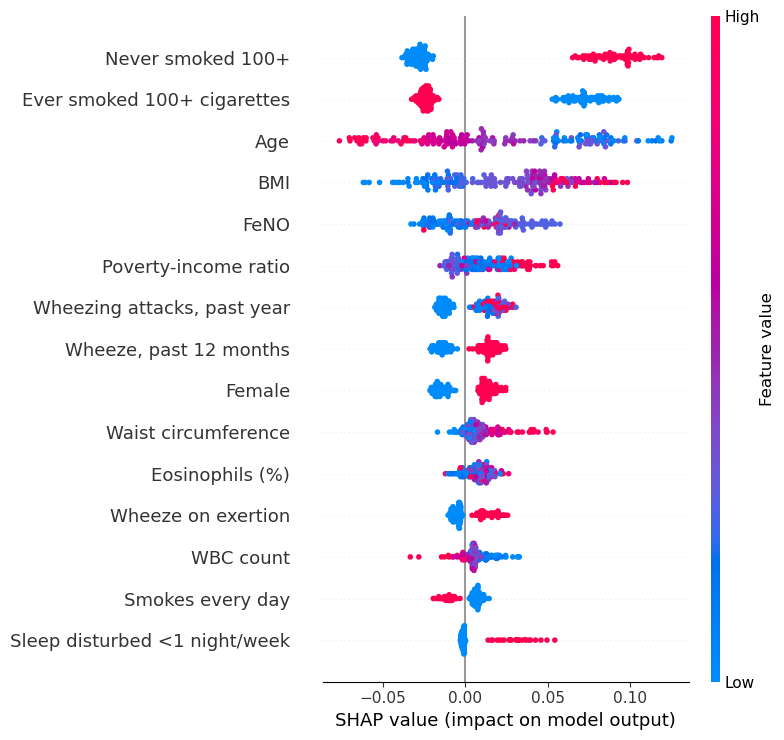

In [58]:
LABELS = {
    "age": "Age",
    "bmi": "BMI",
    "waist_circumference": "Waist circumference",
    "poverty_income_ratio": "Poverty-income ratio",
    "wbc_count": "WBC count",
    "eosinophil_pct": "Eosinophils (%)",
    "eosinophil_count": "Eosinophil count",
    "feno_mean": "FeNO",
    "wheeze_attacks_past_yr": "Wheezing attacks, past year",
    "ever_smoked_100": "Ever smoked 100+ cigarettes",
    "gender": "Sex",
    "current_smoking_status": "Current smoking status",
    "work_status": "Work status",
    "education": "Education",
    "cough_most_days_3mo": "Cough most days, 3+ months",
    "phlegm_most_days_3mo": "Phlegm most days, 3+ months",
    "wheeze_past_12mo": "Wheeze, past 12 months",
    "wheeze_exercise": "Wheeze on exertion",
    "wheeze_disturbs_sleep": "Wheeze disturbing sleep",
    "dry_cough_night": "Dry cough at night",
}

# For binary variables, which dummy level to keep and how to name it.
KEEP_LEVEL = {
    "ever_smoked_100":      ("1.0", "Ever smoked 100+ cigarettes"),
    "gender":               ("2.0", "Female"),
    "cough_most_days_3mo":  ("1.0", "Cough most days, 3+ months"),
    "phlegm_most_days_3mo": ("1.0", "Phlegm most days, 3+ months"),
    "wheeze_past_12mo":     ("1.0", "Wheeze, past 12 months"),
    "wheeze_exercise":      ("1.0", "Wheeze on exertion"),
    "dry_cough_night":      ("1.0", "Dry cough at night"),
}

LEVEL_LABELS = {
    "current_smoking_status_0.0": "Never smoked 100+",
    "current_smoking_status_1.0": "Smokes every day",
    "current_smoking_status_2.0": "Smokes some days",
    "current_smoking_status_3.0": "Former smoker (not at all)",
    # RDQ090 is ordinal, not binary, so all three levels are kept.
    "wheeze_disturbs_sleep_0.0": "Sleep never disturbed",
    "wheeze_disturbs_sleep_1.0": "Sleep disturbed 1+ nights/week",
    "wheeze_disturbs_sleep_2.0": "Sleep disturbed <1 night/week",
    "work_status_1.0": "Working",
    "work_status_2.0": "Employed, not at work",
    "work_status_3.0": "Looking for work",
    "work_status_4.0": "Not working",
    "education_1.0": "Less than 9th grade",
    "education_2.0": "9th-11th grade",
    "education_3.0": "High school graduate / GED",
    "education_4.0": "Some college or AA degree",
    "education_5.0": "College graduate or above",
}


def split_feature(name):
    """Return (base_variable, level_or_None)."""
    m = re.match(r"^(.*)_(-?\d+\.\d+)$", name)
    return (m.group(1), m.group(2)) if m else (name, None)


def shap_publication_figure(X, y, numeric_cols, categorical_cols,
                            model_name="Random Forest", n_iter=30, top_n=15,
                            plot=True, tag="final"):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
    spw = (y_tr == 0).sum() / (y_tr == 1).sum()
    prep = build_preprocessor(categorical_cols, numeric_cols)
    clf, params = get_model_specs(spw)[model_name]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    search = make_search(clf, params, prep, n_iter, cv)
    search.fit(X_tr, y_tr)
    pipe = search.best_estimator_

    prep_f, clf_f = pipe.named_steps["prep"], pipe.named_steps["clf"]
    names = get_feature_names(prep_f, numeric_cols, categorical_cols)
    X_enc = prep_f.transform(X_te)
    if hasattr(X_enc, "toarray"):
        X_enc = X_enc.toarray()

    sv = shap.TreeExplainer(clf_f).shap_values(X_enc)
    if isinstance(sv, list):
        sv = sv[1]
    elif sv.ndim == 3:
        sv = sv[:, :, 1]

    mean_abs = np.abs(sv).mean(axis=0)
    meta = pd.DataFrame({"feature": names, "mean_abs_shap": mean_abs})
    meta[["base", "level"]] = meta["feature"].apply(
        lambda s: pd.Series(split_feature(s)))

    # Panel A: summed mean |SHAP| by original variable.
    grouped = (meta.groupby("base")["mean_abs_shap"].sum()
               .sort_values(ascending=False).reset_index())
    grouped["label"] = grouped["base"].map(LABELS).fillna(grouped["base"])
    print(f"=== Summed mean |SHAP| by original variable ({tag}) ===")
    print(grouped[["label", "mean_abs_shap"]].head(top_n)
          .round(4).to_string(index=False))

    if plot:
        g = grouped.head(top_n).iloc[::-1]
        plt.figure(figsize=(7, 0.38 * len(g) + 1))
        plt.barh(g["label"], g["mean_abs_shap"], color="#4878A6")
        plt.xlabel("Summed mean |SHAP| value")
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / f"fig_shap_grouped_{tag}.png",
                    dpi=300, bbox_inches="tight")
        plt.show()

        # Panel B: drop mirrored dummies, relabel.
        keep_idx, keep_labels, dropped = [], [], []
        for i, row in meta.iterrows():
            base, lvl = row["base"], row["level"]
            if lvl is None:                                  # numeric
                keep_idx.append(i); keep_labels.append(LABELS.get(base, base)); continue
            if base in KEEP_LEVEL:                           # binary -> one dummy
                want, lab = KEEP_LEVEL[base]
                if lvl == want:
                    keep_idx.append(i); keep_labels.append(lab)
                else:
                    dropped.append(row["feature"])
                continue
            key = f"{base}_{lvl}"                            # multi-level -> keep all
            keep_idx.append(i)
            keep_labels.append(LEVEL_LABELS.get(key, key.replace("_", " ")))

        print(f"\nBeeswarm: {len(keep_idx)} of {len(names)} columns retained "
              f"({len(dropped)} mirrored dummies removed)")
        # Panel A sums over every column; Panel B hides the mirrored ones.
        # Print them so the two panels can be reconciled in the caption.
        if dropped:
            print("  hidden from beeswarm:", ", ".join(dropped))

        shap.summary_plot(sv[:, keep_idx], X_enc[:, keep_idx],
                          feature_names=keep_labels, max_display=top_n, show=False)
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / f"fig_shap_beeswarm_{tag}.png",
                    dpi=300, bbox_inches="tight")
        plt.show()

    grouped.to_csv(RESULTS_DIR / f"shap_grouped_importance_{tag}.csv", index=False)
    return grouped, meta, sv, X_enc


X_d, num_d, cat_d = make_arm(X, ARMS["D_final"])
grouped_d, meta_d, sv_d, X_enc_d = shap_publication_figure(
    X_d, y, num_d, cat_d, model_name="Random Forest", tag="armD")

### 12a. Sensitivity: FeNO importance under complete cases

FeNO is imputed for a much larger share of asthma cases than COPD cases, so its
apparent importance may partly reflect the missingness pattern rather than the
biomarker.

**Corrected arm.** The original ran this comparison on Arm C — spirometry-free but
still including race/ethnicity — while the manuscript describes it as Arm D. It now
runs on Arm D, against the Arm D baseline fitted above.

In [59]:
# FIX 13: Arm D, not Arm C.
feno_obs = X["feno_mean"].notna()
print(f"Complete FeNO: {feno_obs.sum()} of {len(X)} "
      f"({feno_obs.sum()/len(X)*100:.1f}%)")
print("By group:", y[feno_obs].value_counts().to_dict())
print("Imputed share — asthma "
      f"{1 - feno_obs[y == 1].mean():.2f}, COPD {1 - feno_obs[y == 0].mean():.2f}")

X_f, y_f = X[feno_obs], y[feno_obs]
X_fd, num_fd, cat_fd = make_arm(X_f, ARMS["D_final"])

grouped_feno, meta_feno, _, _ = shap_publication_figure(
    X_fd, y_f, num_fd, cat_fd, model_name="Random Forest",
    plot=False, tag="armD_completeFeNO")

cmp = (meta_d[["feature", "mean_abs_shap"]].rename(columns={"mean_abs_shap": "with_imputed"})
       .merge(meta_feno[["feature", "mean_abs_shap"]]
              .rename(columns={"mean_abs_shap": "complete_only"}),
              on="feature", how="outer"))
cmp["rank_imputed"] = cmp["with_imputed"].rank(ascending=False)
cmp["rank_complete"] = cmp["complete_only"].rank(ascending=False)
print("\n=== FeNO / eosinophil rank comparison (Arm D) ===")
print(cmp[cmp.feature.str.contains("feno|eosinophil", case=False, na=False)]
      .round(4).to_string(index=False))
cmp.to_csv(RESULTS_DIR / "shap_feno_sensitivity.csv", index=False)

# If FeNO's rank falls sharply here, its position in the Arm D figure above is
# partly an imputation artefact and the results text must say so.

Complete FeNO: 666 of 922 (72.2%)
By group: {1: 548, 0: 118}
Imputed share — asthma 0.31, COPD 0.08
=== Summed mean |SHAP| by original variable (armD_completeFeNO) ===
                      label  mean_abs_shap
Ever smoked 100+ cigarettes         0.0884
                        Age         0.0743
     Current smoking status         0.0685
                        BMI         0.0396
                        Sex         0.0295
       Poverty-income ratio         0.0290
    Wheeze disturbing sleep         0.0242
                Work status         0.0181
Phlegm most days, 3+ months         0.0181
        Waist circumference         0.0181
            Eosinophils (%)         0.0168
                  Education         0.0146
                       FeNO         0.0141
         Wheeze on exertion         0.0125
     Wheeze, past 12 months         0.0120

=== FeNO / eosinophil rank comparison (Arm D) ===
         feature  with_imputed  complete_only  rank_imputed  rank_complete
eosinophil_count  